# Statistical Mechanics of Money: time evolution

This notebook recreates the Mathematica Demonstration in Python. It records the same two observables: the money distribution and the entropy of the economies.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, display

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

NUM_AGENTS = 25
NUM_ECONOMIES = 20
INITIAL_MONEY = 100.0
NUM_SAMPLES = 50
STEP_SIZE = 5
RANDOM_SEED = 7

## Model and recorded history

The Mathematica source selects a donor and receiver independently and transfers a random amount between zero and the initial endowment. The Python version preserves that behavior, including skipped self-transfers and unaffordable transfers.

In [2]:
def random_exchange(agents, endowment, rng):
    updated = agents.copy()
    donor, receiver = rng.integers(0, len(updated), size=2)
    amount = rng.random() * endowment
    if updated[donor] >= amount:
        updated[donor] -= amount
        updated[receiver] += amount
    return updated


def entropy(agents):
    counts = np.bincount(np.floor(agents).astype(int), minlength=int(np.ceil(agents.sum())) + 1)
    probabilities = counts[counts > 0] / len(agents)
    return float(-np.dot(probabilities, np.log(probabilities)))


def run_simulation(economies, endowment, exchanges, rng):
    updated = economies.copy()
    for _ in range(exchanges):
        updated = np.array([random_exchange(economy, endowment, rng) for economy in updated])
    return updated


def make_data(num_agents=NUM_AGENTS, num_economies=NUM_ECONOMIES,
              initial_money=INITIAL_MONEY, num_samples=NUM_SAMPLES,
              step_size=STEP_SIZE, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    economies = np.full((num_economies, num_agents), initial_money, dtype=float)
    money_history = []
    entropy_history = []
    for _ in range(num_samples):
        money_history.append(economies.ravel().copy())
        entropy_history.append(np.mean([entropy(economy) for economy in economies]))
        economies = run_simulation(economies, initial_money, step_size, rng)
    return np.array(money_history), np.array(entropy_history)

money_history, entropy_history = make_data()
assert money_history.shape == (NUM_SAMPLES, NUM_AGENTS * NUM_ECONOMIES)
assert np.allclose(money_history.sum(axis=1), NUM_AGENTS * NUM_ECONOMIES * INITIAL_MONEY)
assert np.isfinite(entropy_history).all()
print(f"Recorded {len(money_history)} snapshots for {money_history.shape[1]} agents.")
print(f"Total money: {money_history[0].sum():.1f} at every snapshot.")

Recorded 50 snapshots for 500 agents.
Total money: 50000.0 at every snapshot.


## Inspect one snapshot

Use `snapshot` to inspect the initial, an intermediate, or the final state.

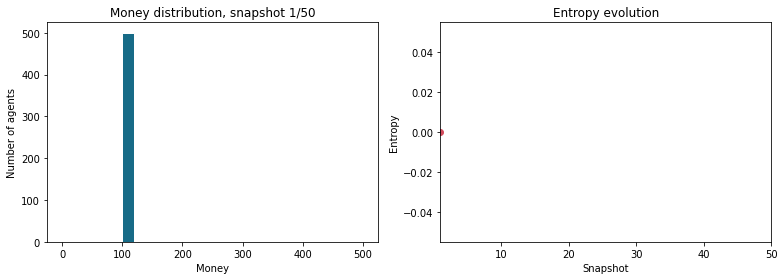

In [3]:
def plot_snapshot(snapshot, money_history=money_history, entropy_history=entropy_history):
    snapshot = int(np.clip(snapshot, 0, len(money_history) - 1))
    figure, (histogram_axis, entropy_axis) = plt.subplots(1, 2, figsize=(11, 4))
    histogram_axis.hist(money_history[snapshot], bins=25, range=(0, 500), color="#176b87", edgecolor="white")
    histogram_axis.set(title=f"Money distribution, snapshot {snapshot + 1}/{len(money_history)}", xlabel="Money", ylabel="Number of agents")
    entropy_axis.plot(np.arange(1, snapshot + 2), entropy_history[:snapshot + 1], color="#d1495b", linewidth=2)
    entropy_axis.scatter(snapshot + 1, entropy_history[snapshot], color="#d1495b")
    entropy_axis.set(title="Entropy evolution", xlabel="Snapshot", ylabel="Entropy", xlim=(1, len(money_history)))
    figure.tight_layout()
    return figure

plot_snapshot(0)
plt.show()

In [4]:
try:
    import ipywidgets as widgets

    def show_snapshot(snapshot=0):
        figure = plot_snapshot(snapshot)
        plt.show()

    slider = widgets.IntSlider(value=0, min=0, max=len(money_history) - 1, step=1, description="Snapshot")
    display(widgets.interactive(show_snapshot, snapshot=slider))
except ImportError:
    print("ipywidgets is unavailable; use plot_snapshot(0), plot_snapshot(25), or plot_snapshot(49).")

interactive(children=(IntSlider(value=0, description='Snapshot', max=49), Output()), _dom_classes=('widget-int…

## Automatic animation

The same recorded history can be replayed automatically. The GIF is saved separately so it can be opened outside Jupyter.

In [5]:
figure, (histogram_axis, entropy_axis) = plt.subplots(1, 2, figsize=(11, 4))

def update(frame):
    histogram_axis.clear()
    entropy_axis.clear()
    histogram_axis.hist(money_history[frame], bins=25, range=(0, 500), color="#176b87", edgecolor="white")
    histogram_axis.set(title=f"Money distribution, snapshot {frame + 1}/{len(money_history)}", xlabel="Money", ylabel="Number of agents", xlim=(0, 500))
    entropy_axis.plot(np.arange(1, frame + 2), entropy_history[:frame + 1], color="#d1495b", linewidth=2)
    entropy_axis.scatter(frame + 1, entropy_history[frame], color="#d1495b")
    entropy_axis.set(title="Entropy evolution", xlabel="Snapshot", ylabel="Entropy", xlim=(1, len(money_history)))
    figure.tight_layout()

animation = FuncAnimation(figure, update, frames=len(money_history), interval=120, repeat=True)
gif_path = OUTPUT_DIR / "money_evolution.gif"
animation.save(gif_path, writer=PillowWriter(fps=8))
plt.close(figure)
print(f"Saved {gif_path} ({gif_path.stat().st_size:,} bytes).")
HTML(animation.to_jshtml())

Saved outputs/money_evolution.gif (421,968 bytes).
